# Charts to visualise our data

## Imports 

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Read in the data

In [11]:
credit_score_df = pd.read_csv("Credit_Score_Train.csv")
credit_score_df.head()

,Unnamed: 0,ID,IntRate,Income,DTI,LoanAmt,HistLen,Utilisation,Age,EmpStatus,HomeOwn,Purpose,default,X,Gender,Education,Offences
0,4549,51334,21.75,354013,1.69,900314.0,23.09,77.52,51.5,Salaried,Rent,Other,1,4548,Male,Grade 12,0
1,6555,69690,16.75,256743,1.27,641415.0,25.91,89.34,52.6,Salaried,Mortgage,Home_improvement,1,6554,Female,Diploma,2
2,6663,70637,19.75,970741,1.60,2779195.0,20.92,72.43,53.0,Self-employed,Mortgage,Vehicle,0,6662,Male,Grade 12,3
3,2288,30693,18.75,223580,1.71,669467.0,21.61,73.16,50.9,Salaried,Rent,Vehicle,0,2287,Female,Diploma,0
4,2377,31589,24.25,397232,1.97,568682.0,33.15,112.96,67.7,Contract,Own,Debt_consolidation,0,2376,Male,Degree,1


## 2.) Histogram to check the distribution of our variables

* 2.1) Check IntRate's density

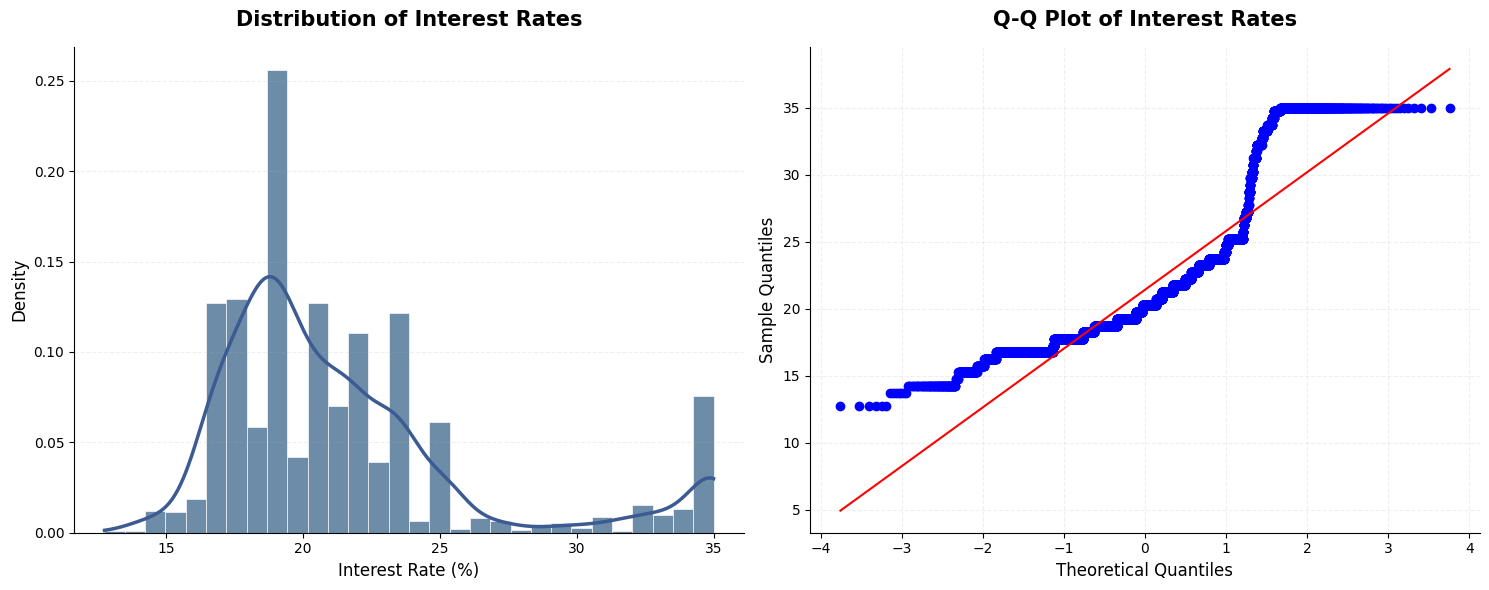

In [45]:
IntRate =  np.array(credit_score_df["IntRate"])
dd_IntRate = stats.gaussian_kde(IntRate)
xval=np.linspace(np.min(IntRate), np.max(IntRate),num=1000)

# Create a figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    IntRate,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="Interest Rate Distribution"
)

axes[0].plot(
    xval,
    dd_IntRate(xval),
    color="#3B5B92",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of Interest Rates",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Interest Rate (%)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    IntRate,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Interest Rates",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "interest_rate_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




**These graphs tell us that the interest rates are not normally distributed. We can see that it has a right tail and is thus skewed to the right. This tells us that we might run into some extreme values that should be modeled. I believe this might be due to people with very low income, and that has a very high chance of defaulting. This shows us that if you lie in the tail, then you will probably not be approved for a loan**

* 2.2) Check Income's density

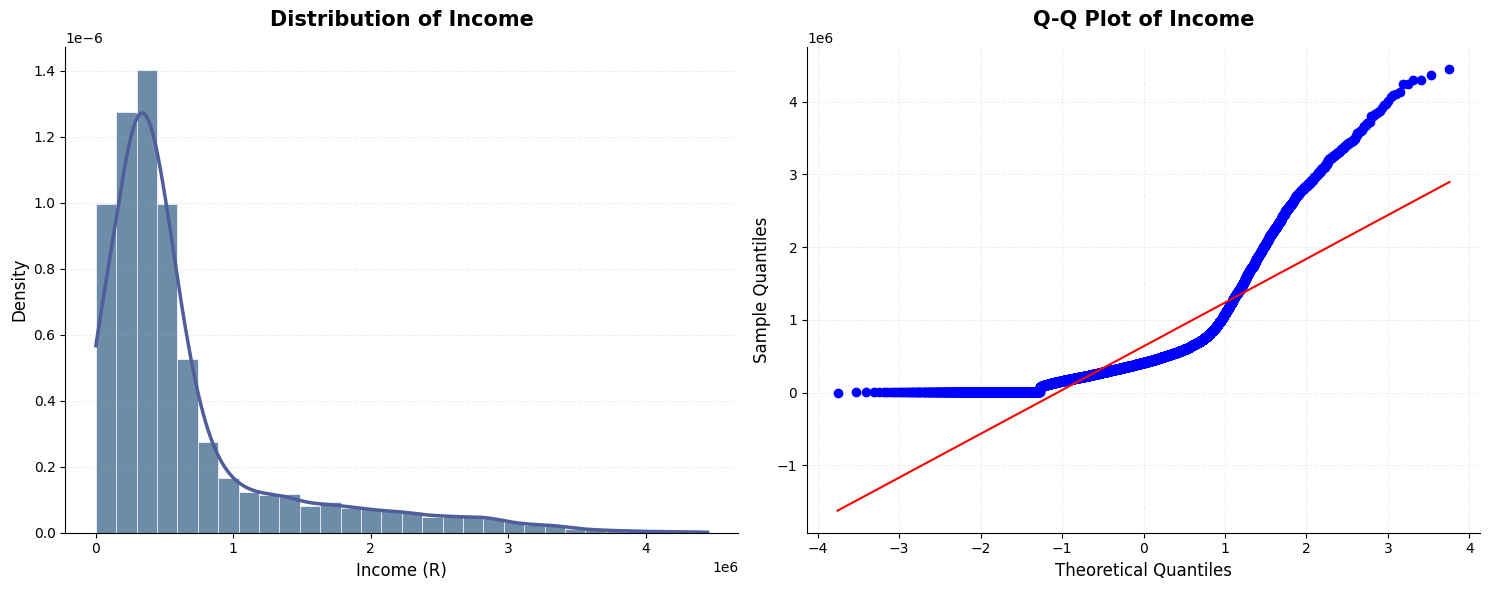

In [46]:
Income = np.array(credit_score_df["Income"])
dd_Income = stats.gaussian_kde(Income)
xval = np.linspace(np.min(Income),np.max(Income), 1000)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    Income,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="Income Distribution"
)

axes[0].plot(
    xval,
    dd_Income(xval),
    color="#4F5D9A",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of Income",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Income (R)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    Income,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Income",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                 

**We can clearly see the big tail of the income distribution. This seems like it follows a pareto distribution which is heavily skewed to the right. It is also well known that income usually follow a pareto distribution. Income might be different to different classes of education, which mean we will need to studentize this data. We will check this later on, but for now we can safely assume that income is not normally distributed with most people earning relatively low in comparison with the end values.**

* 2.3) Check DTI's density

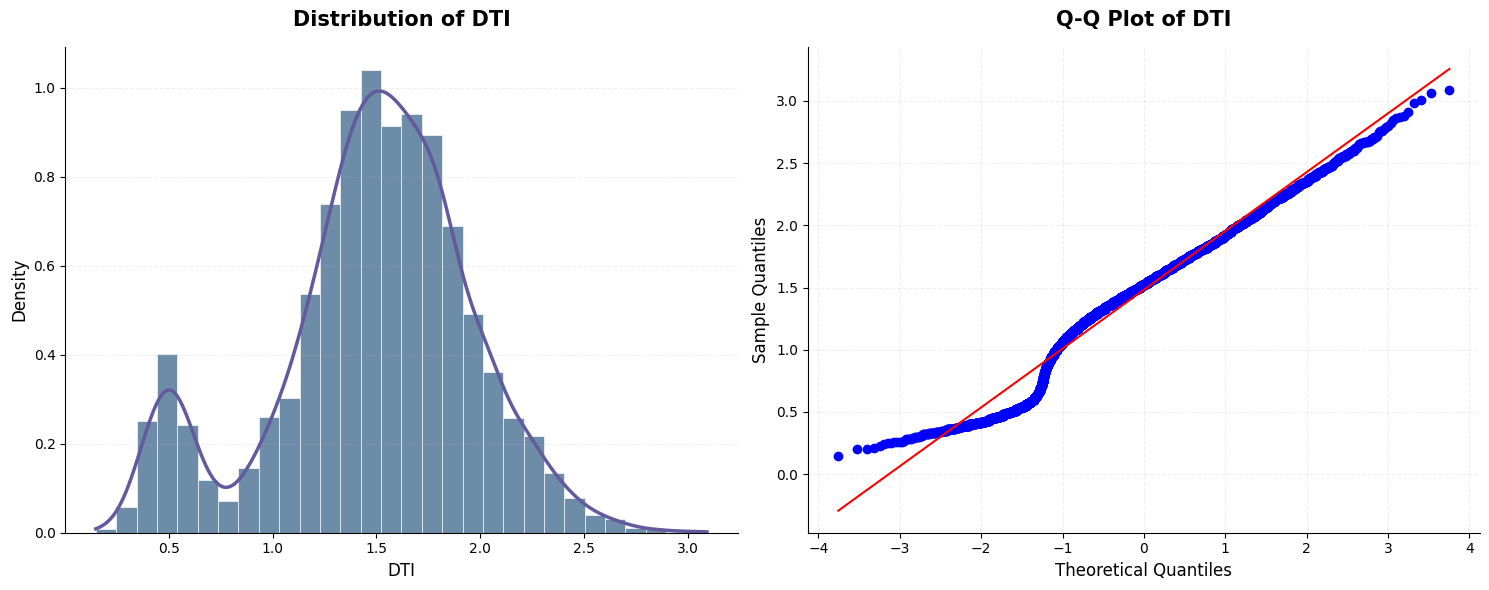

In [47]:
DTI = np.array(credit_score_df["DTI"])
dd_DTI = stats.gaussian_kde(DTI)
xval = np.linspace(np.min(DTI),np.max(DTI), 1000)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    DTI,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="DTI Distribution"
)

axes[0].plot(
    xval,
    dd_DTI(xval),
    color="#635A9E",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of DTI",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("DTI", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    DTI,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of DTI",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "DTI_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                 

**The distrubution for DTI looks more normal with the exception of a spike in low values. This might be due to some categories be lower than other. Will retest after studentising**

* 2.4) Check distribution of LoanAmt (Expected to be normally distributed)

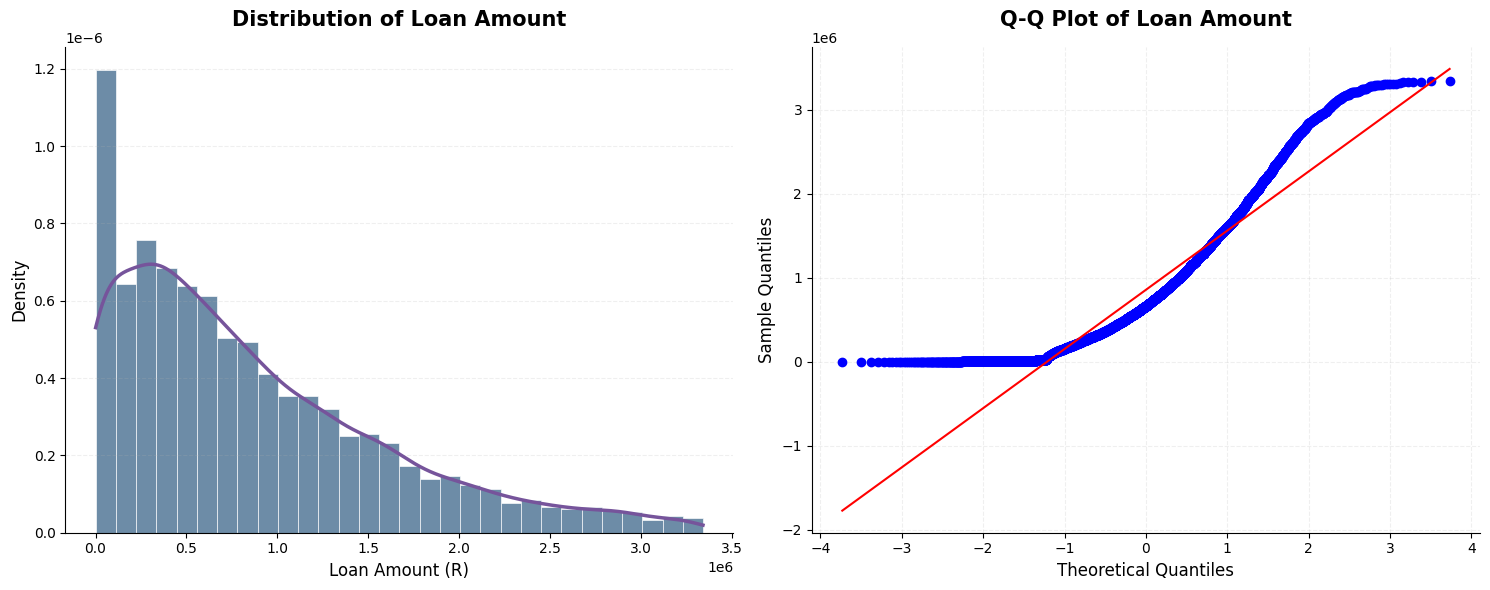

In [48]:
LoanAmt = np.array(credit_score_df["LoanAmt"])

# Remove outliers to see the data better
Q1 = np.percentile(LoanAmt, 25)
Q3 = np.percentile(LoanAmt, 75)
Qr = Q3 - Q1

lower_bound = Q1 - 1.5 * Qr
upper_bound = Q3 + 1.5 * Qr

LoanAmt_clean = LoanAmt[(LoanAmt >= lower_bound) & (LoanAmt <= upper_bound)]

dd_LoanAmt = stats.gaussian_kde(LoanAmt_clean)
xval = np.linspace(np.min(LoanAmt_clean),np.max(LoanAmt_clean), 1000)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    LoanAmt_clean,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="Loan Amount Distribution"
)

axes[0].plot(
    xval,
    dd_LoanAmt(xval),
    color="#76549B",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of Loan Amount",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Loan Amount (R)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    LoanAmt_clean,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Loan Amount",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "loan_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                 

**We can see that the loan amount is also skewed to the right. We removed outliers using the quantile method in this graph. We might keep in these outliers in the model as we still have to account for big loans that will be given out, but to visualise where most of the data sits we removed outliers. We can thus see that the loan amount is most likely not normally distributed.**

* 2.5) Hisory length's density

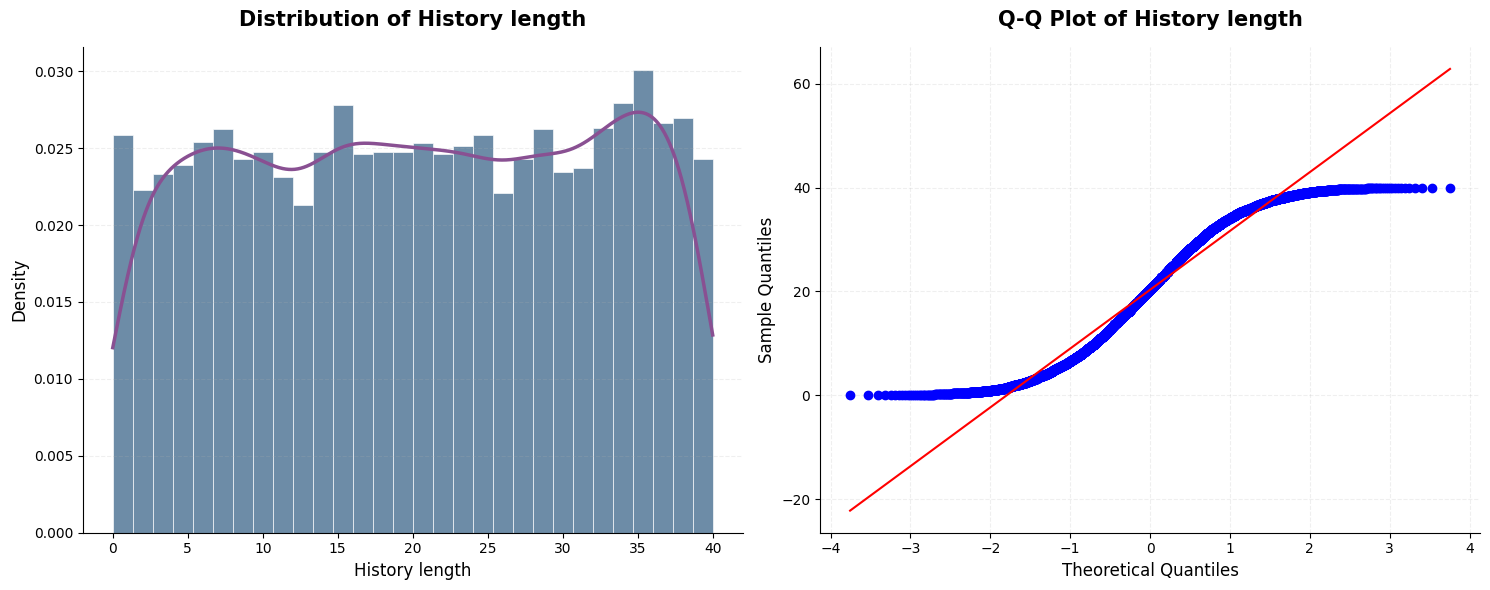

In [50]:
HistLen = np.array(credit_score_df["HistLen"])
dd_HistLen = stats.gaussian_kde(HistLen)
xval = np.linspace(np.min(HistLen),np.max(HistLen), 1000)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    HistLen,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="DTI Distribution"
)

axes[0].plot(
    xval,
    dd_HistLen(xval),
    color="#895092",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of History length",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("History length", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    HistLen,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of History length",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "HistLen_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                 

**This data is approcimately uniformly distributed, as it is almost flat on top with minor deviations. This was expected.**

* 2.6) Check Utilisation's density

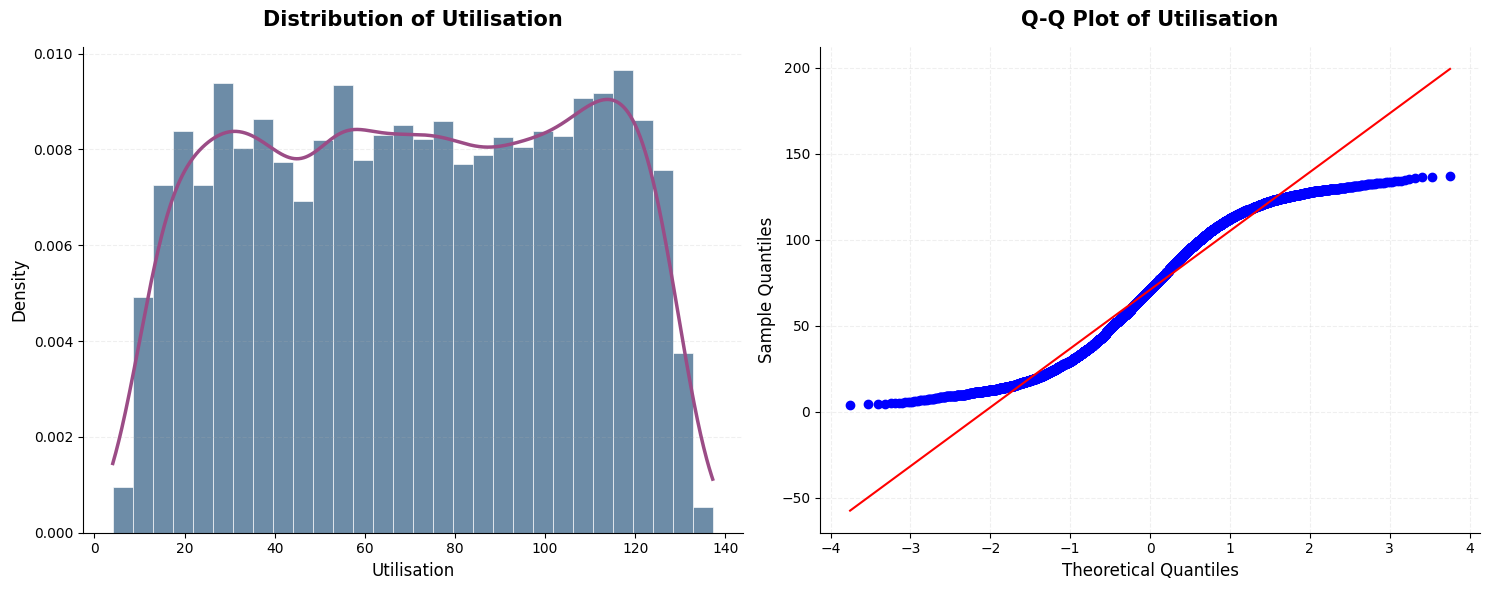

In [52]:
Utilisation = np.array(credit_score_df["Utilisation"])
dd_Utilisation = stats.gaussian_kde(Utilisation)
xval = np.linspace(np.min(Utilisation),np.max(Utilisation), 1000)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    Utilisation,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="Utilisation Distribution"
)

axes[0].plot(
    xval,
    dd_Utilisation(xval),
    color="#9B4C86",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of Utilisation",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Utilisation", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    Utilisation,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Utilisation",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "utilisation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                 

**The utilisation density is approximately normally distributed**

* 2.7) Age's distribution

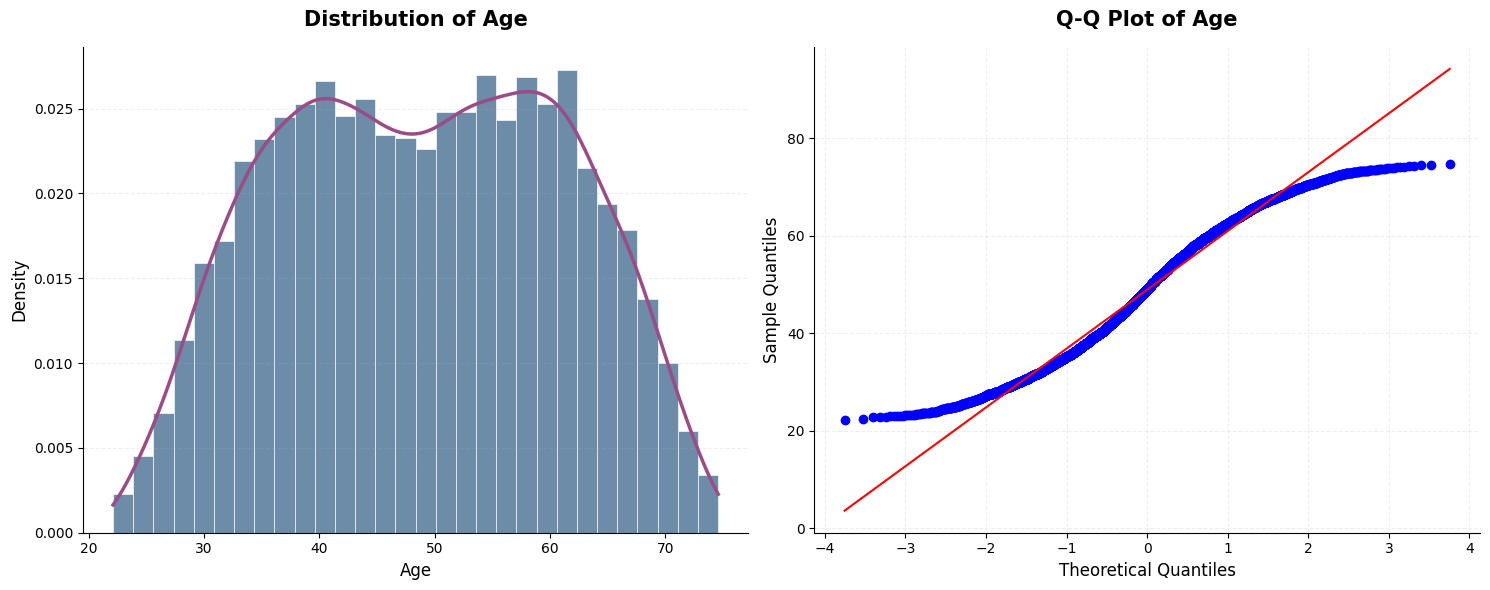

In [53]:
Age = np.array(credit_score_df["Age"])
dd_Age = stats.gaussian_kde(Age)
xval = np.linspace(np.min(Age),np.max(Age), 1000)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram + KDE

axes[0].hist(
    Age,
    bins=30,
    density=True,
    alpha=0.65,
    color="#1F4E79",
    edgecolor="white",
    linewidth=0.7,
    label="Age Distribution"
)

axes[0].plot(
    xval,
    dd_Age(xval),
    color="#9B4C86",
    linewidth=2.5,
    label="Kernel Density Estimate"
)

axes[0].set_title(
    "Distribution of Age",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Age", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

axes[0].grid(
    axis="y",
    alpha=0.2,
    linestyle="--"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Q-Q Plot

stats.probplot(
    Age,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot of Age",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[1].set_ylabel("Sample Quantiles", fontsize=12)

axes[1].grid(
    alpha=0.2,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)


plt.tight_layout()

plt.savefig(
    "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()                 

**Age is approximately normally distributed. This plot does not provide us with too much information but it is a good thing to see that we have a good variaty of ages, which our model can predict, otherwise our model might become bias too age. Age is a variable that cannot be used to predict if someone can get a loan according to the National Credit Act. Thus, this variable will not be used in the model but it is good to inspect to see if we have enough variation in age which we do have**

# 3.) Use barchart too see the significance of categorical variables on our interest rate (predicted variable)

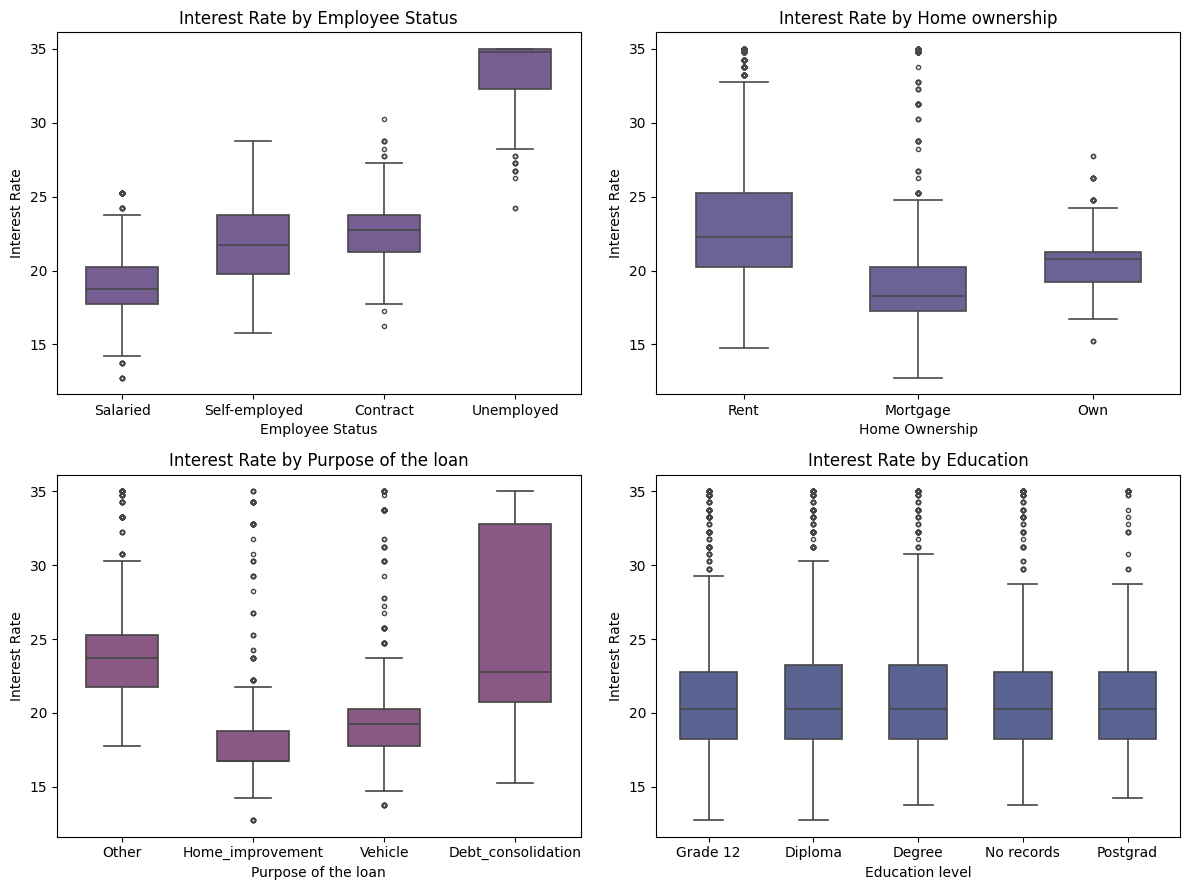

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(
    data=credit_score_df,
    x="EmpStatus",
    y="IntRate",
    ax=axes[0,0],
    color="#76549B",
    width=0.55,
    linewidth=1.2,
    fliersize=3
)
axes[0, 0].set_title("Interest Rate by Employee Status")
axes[0, 0].set_xlabel("Employee Status")
axes[0, 0].set_ylabel("Interest Rate")


sns.boxplot(
    data=credit_score_df,
    x="HomeOwn",
    y="IntRate",
    ax=axes[0,1],
    color="#635A9E",
    width=0.55,
    linewidth=1.2,
    fliersize=3
)
axes[0, 1].set_title("Interest Rate by Home ownership")
axes[0, 1].set_xlabel("Home Ownership")
axes[0, 1].set_ylabel("Interest Rate")

sns.boxplot(
    data=credit_score_df,
    x="Purpose",
    y="IntRate",
    ax=axes[1,0],
    color="#92508B",
    width=0.55,
    linewidth=1.2,
    fliersize=3
)
axes[1, 0].set_title("Interest Rate by Purpose of the loan")
axes[1, 0].set_xlabel("Purpose of the loan")
axes[1, 0].set_ylabel("Interest Rate")

sns.boxplot(
    data=credit_score_df,
    x="Education",
    y="IntRate",
    ax=axes[1,1],
    color="#4F5D9A",
    width=0.55,
    linewidth=1.2,
    fliersize=3
    
)
axes[1, 1].set_title("Interest Rate by Education")
axes[1, 1].set_xlabel("Education level")
axes[1, 1].set_ylabel("Interest Rate")

plt.tight_layout()

plt.savefig(
    "boxplots_relationship_cat_vs_intRate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**1. We can see that the employment type looks like it has an effect on the Interest rate (We might standardize this)\
2. Home ownership does not look like it has a significant effect on interest rates\
3. Purpose of the loans shows some effect on the interest rate charged (We might standardize this)\
4. Education level does not seem to have any effect on the interest rate\
We can also see that there are quite some outliers, which we might want to remove in the future.**

# 4. Get the distribution / comparison of defaults

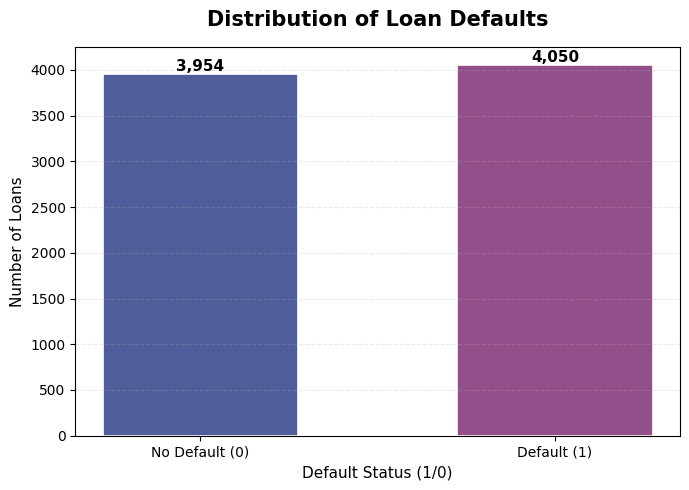

In [75]:
default = credit_score_df["default"]
nms, frq = np.unique(default, return_counts=True)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    nms,
    frq,
    color=["#4F5D9A", "#92508B"],
    width=0.55,
    edgecolor="white",
    linewidth=1.2
)

# Add values above bars
for bar, frequency in zip(bars, frq): # zip pairs bars and frequency
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{frequency:,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Distribution of Loan Defaults",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Default Status (1/0)", fontsize=11)
plt.ylabel("Number of Loans", fontsize=11)

plt.xticks(
    nms,
    ["No Default (0)", "Default (1)"]
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha= 0.25
)


plt.tight_layout()
plt.savefig(
    "loan_default_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**We can see we have slightly more loans that defaulted than thode who did not default. The ratio between defaults and non-defaults is about 1:1 which gives us good variation in people who did not recieve a loan vs. people who did recieve the loan. This means good volume and variation in the data to build a good working model**